# Portfolio Risk Analysis & Backtesting

## Introduction

This notebook presents a comprehensive analysis of portfolio risk and performance metrics using historical stock data. The analysis is divided into three main sections:

1. **Data Preparation and Exploration** - Download and visualize stock price data
2. **Risk Analysis** - Calculate risk metrics and compare portfolio strategies
3. **Backtesting** - Validate VaR models and compare portfolio performance

Each section builds on the previous one and includes visualizations to illustrate key concepts.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import yfinance as yf
import sys
from pathlib import Path

# Add src directory to path
sys.path.insert(0, str(Path.cwd().parent))
from src.metrics import portfolio_metrics, max_drawdown, realized_metrics
from src.portfolio import portfolio_returns_from_assets, optimize_weights_inverse_es

# Configure plotting
plt.rcParams['figure.figsize'] = (14, 6)
sb.set_style("whitegrid")

print("All modules imported successfully!")

All modules imported successfully!


## Section 1: Data Preparation and Exploration

### Download Stock Data

In [32]:
tickers = ["META", "AAPL", "TGT", "EXPD", "UNH", "SBUX", "ZBRA", "MRNA", "ACN", "TSN"]

data = yf.download(
    tickers,
    start="2022-01-01",
    end="2025-01-01",
    auto_adjust=True,
    group_by="ticker"
)

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

[*********************100%***********************]  10 of 10 completed

Data shape: (753, 50)
Date range: 2022-01-03 00:00:00 to 2024-12-31 00:00:00


In [33]:
# Company names mapping
company_names = {
    "META": "Meta Platforms, Inc.",
    "AAPL": "Apple Inc.",
    "ACN": "Accenture plc",
    "MRNA": "Moderna, Inc.",
    "ZBRA": "Zebra Technologies",
    "SBUX": "Starbucks Corporation",
    "EXPD": "Expeditors International",
    "TGT": "Target Corporation",
    "UNH": "UnitedHealth Group",
    "TSN": "Tyson Foods"
}

# Calculate daily returns
Close_price = data.filter(like="Close")
Daily_returns = (Close_price - Close_price.shift(1)) / Close_price.shift(1)
Daily_returns_named = Daily_returns.rename(columns=company_names)

print("Daily returns calculated successfully")

Daily returns calculated successfully


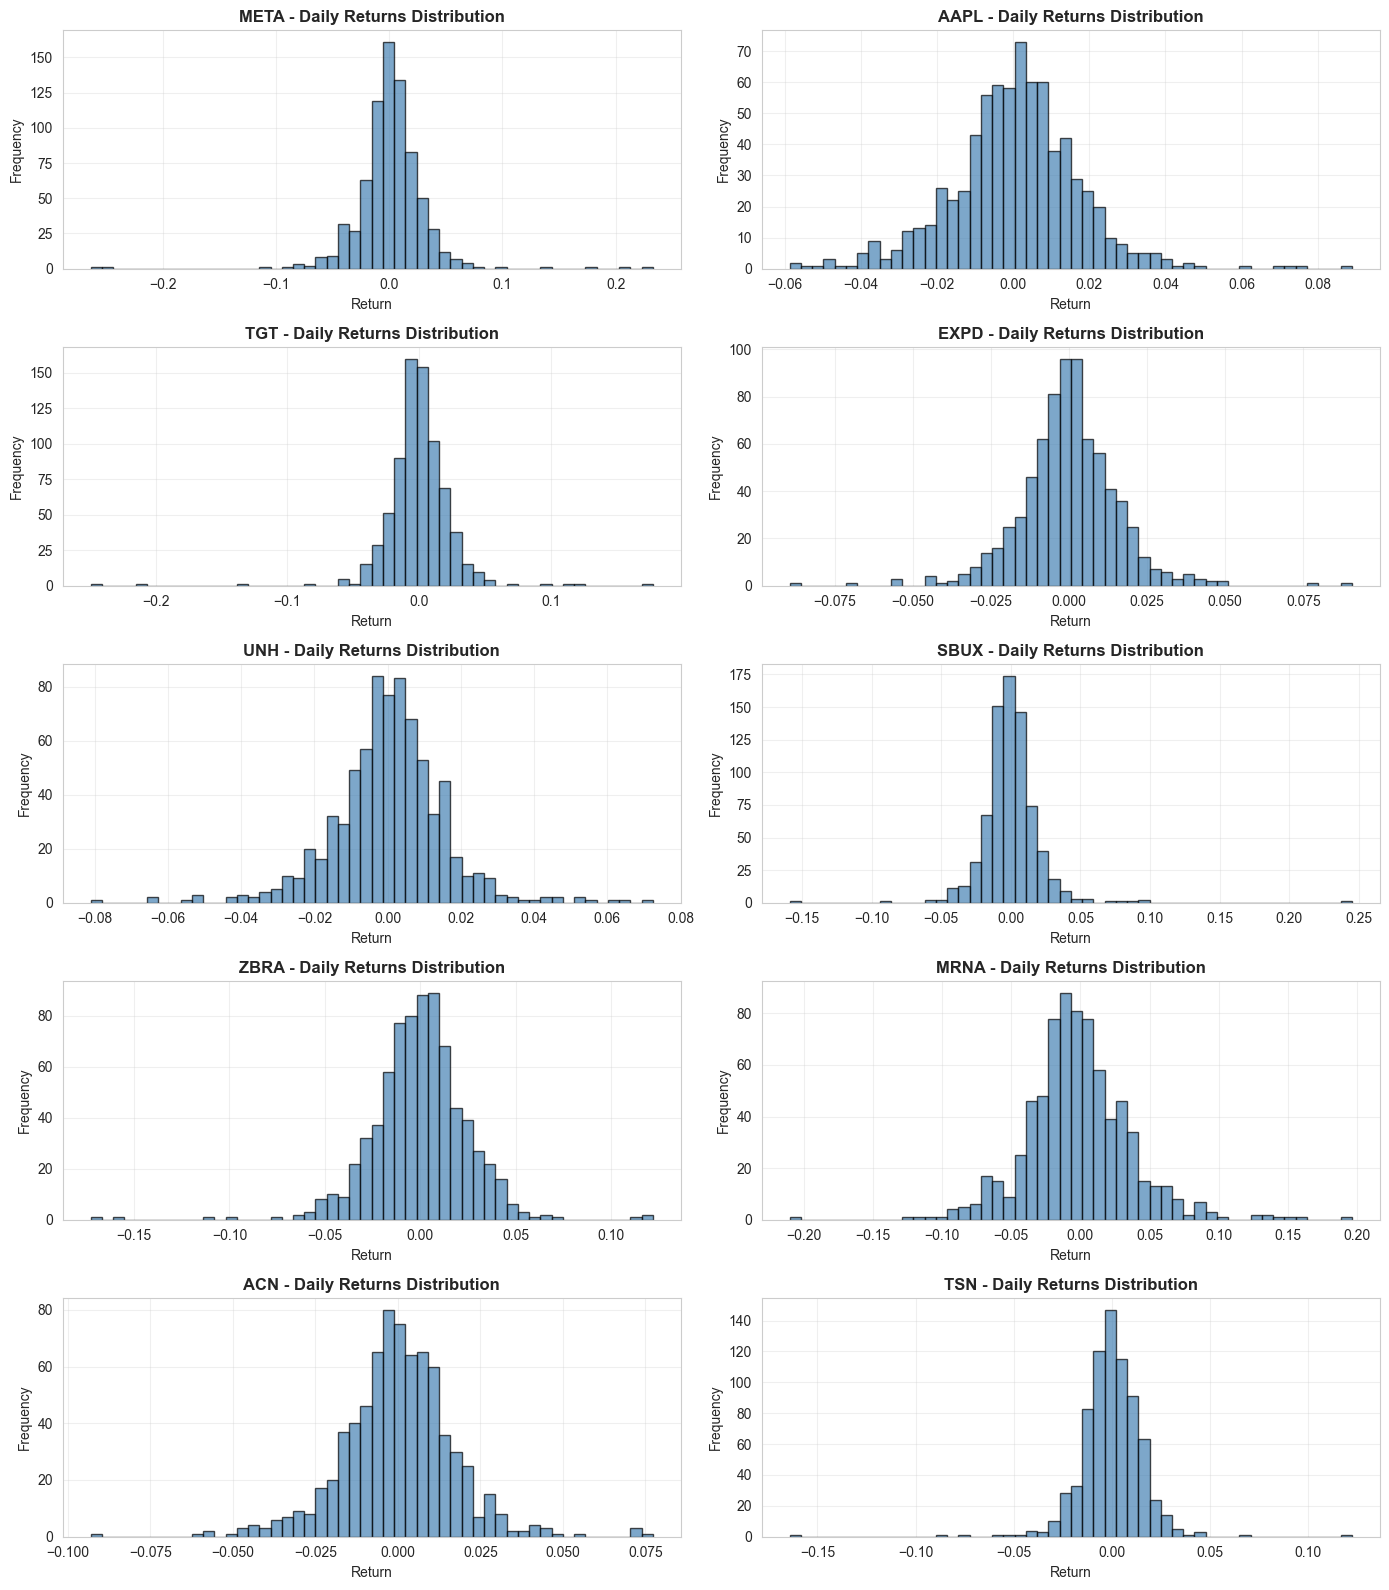

In [34]:
### Returns Distribution Analysis

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, ticker in zip(axes, tickers):
    ax.hist(Daily_returns[ticker], color="steelblue", bins=50, edgecolor="black", alpha=0.7)
    ax.set_title(f"{ticker} - Daily Returns Distribution", fontweight="bold")
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

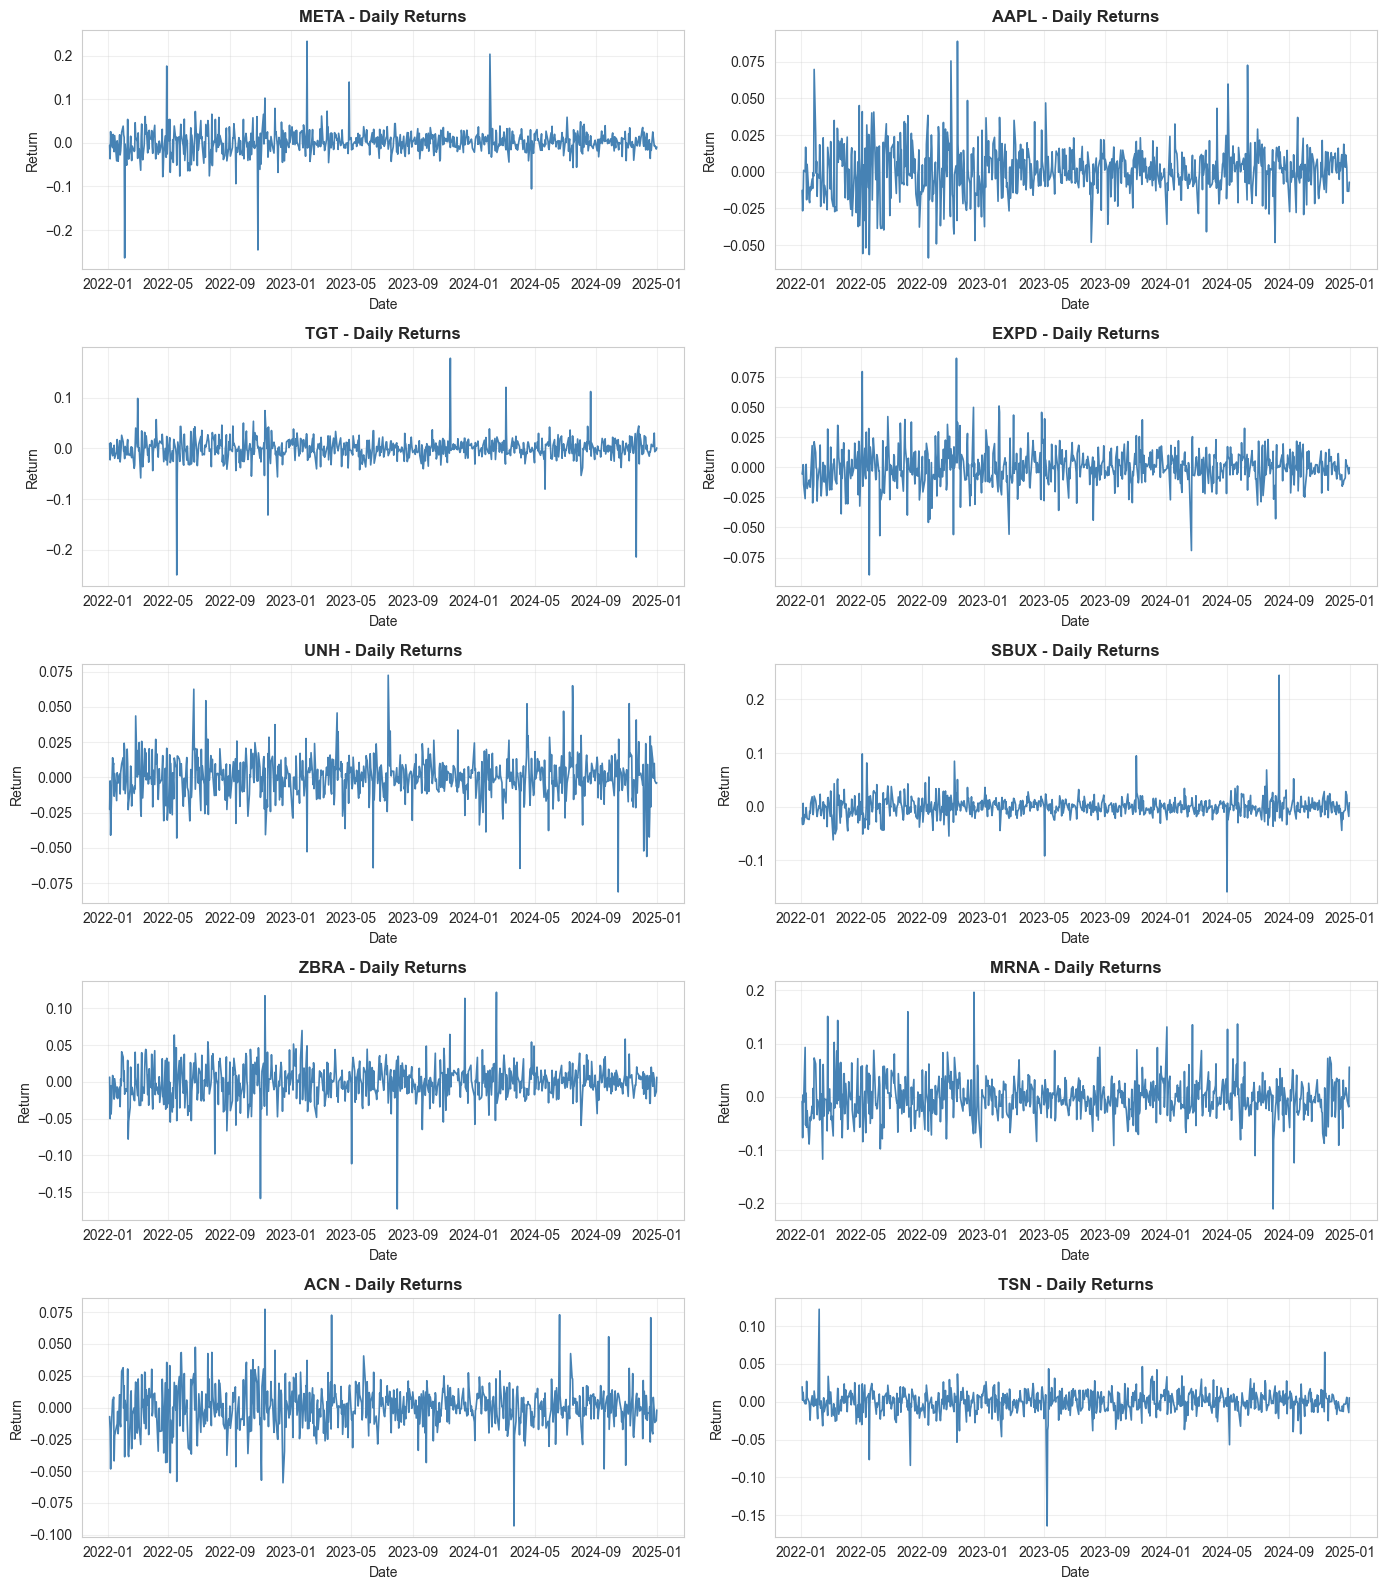

In [35]:
### Returns Time Series Visualization

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, ticker in zip(axes, tickers):
    ax.plot(Daily_returns[ticker], linewidth=1.2, color="steelblue")
    ax.set_title(f"{ticker} - Daily Returns", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

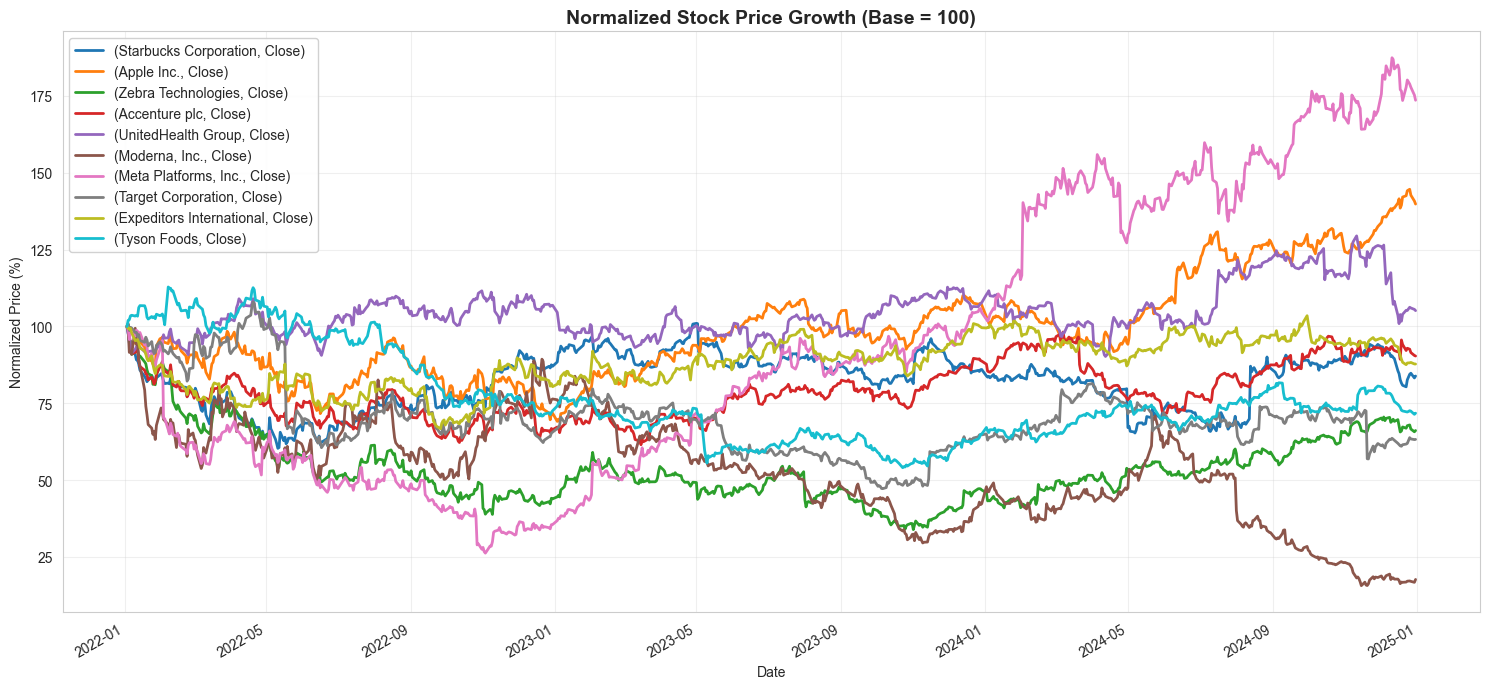

In [36]:
### Normalized Stock Price Growth

normalized_data = (Close_price / Close_price.iloc[0]) * 100
normalized_data = normalized_data.rename(columns=company_names)

plt.figure(figsize=(15, 7))
normalized_data.plot(ax=plt.gca(), linewidth=2)
plt.title("Normalized Stock Price Growth (Base = 100)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Normalized Price (%)")
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

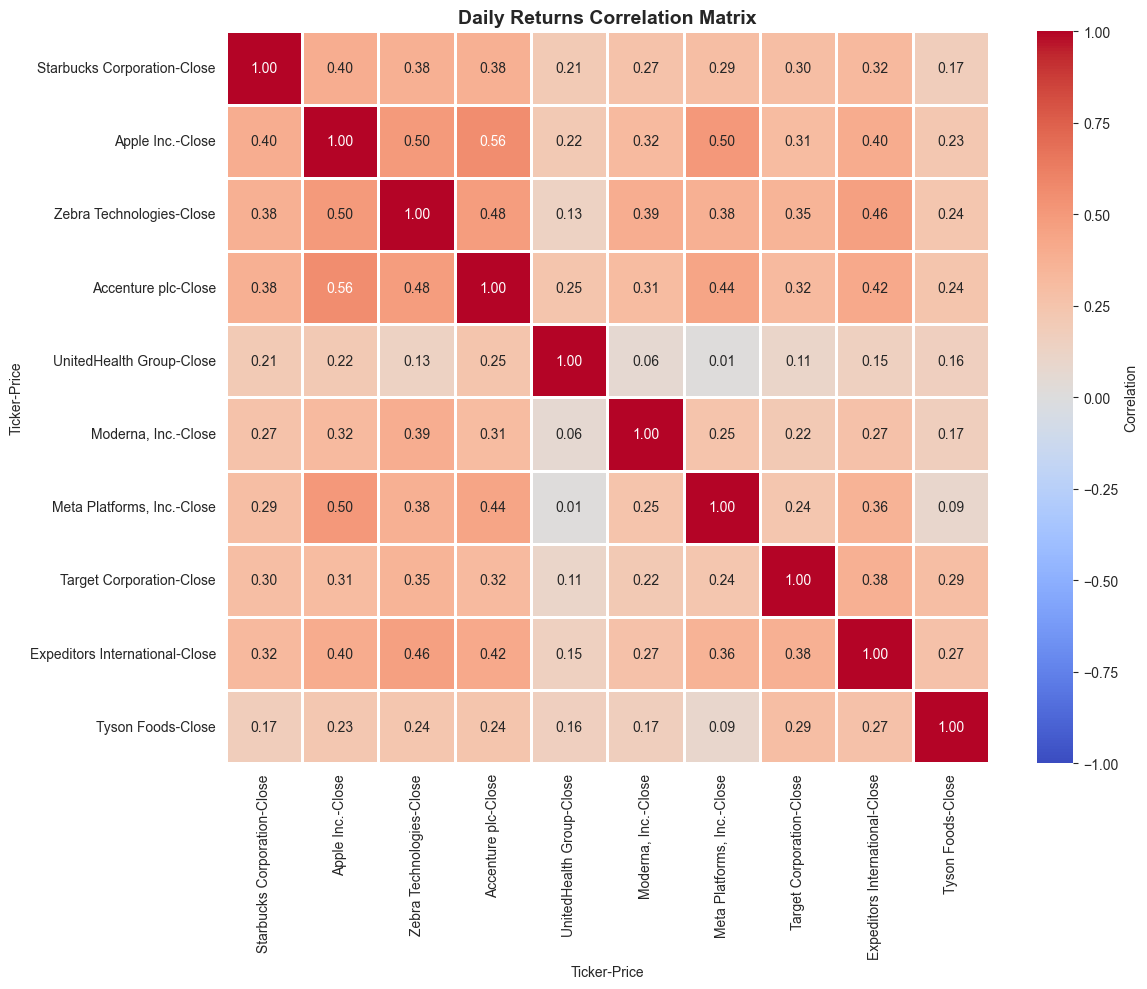


Basic Statistics:
                                   Mean  Std Dev
Ticker                   Price                  
Starbucks Corporation    Close -0.00003  0.02056
Apple Inc.               Close  0.00059  0.01707
Zebra Technologies       Close -0.00023  0.02520
Accenture plc            Close  0.00001  0.01703
UnitedHealth Group       Close  0.00019  0.01537
Moderna, Inc.            Close -0.00158  0.03802
Meta Platforms, Inc.     Close  0.00121  0.03069
Target Corporation       Close -0.00030  0.02432
Expeditors International Close -0.00005  0.01583
Tyson Foods              Close -0.00031  0.01612


In [37]:
### Correlation Analysis

correlation_matrix = Daily_returns_named.corr()

plt.figure(figsize=(12, 10))
sb.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", 
           linewidths=1, cbar_kws={"label": "Correlation"}, vmin=-1, vmax=1)
plt.title("Daily Returns Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nBasic Statistics:")
stats = Daily_returns_named.agg(["mean", "std"]).T
stats.columns = ["Mean", "Std Dev"]
print(round(stats, 5))

## Section 2: Risk Analysis (2022)

### Calculate Risk Metrics for 2022

In [38]:
# Filter data for 2022
Daily_returns_2022 = Daily_returns_named.loc["2022-01-01":"2022-12-31"].dropna()
companies = Daily_returns_2022.columns.unique()

var_level = 0.01
es_level = 0.025

# Calculate individual metrics
mean_series = pd.Series({
    c: Daily_returns_2022[c].mean()
    for c in companies
}, name="Mean (daily)")

std_series = pd.Series({
    c: Daily_returns_2022[c].std(ddof=1)
    for c in companies
}, name="Std (daily)")

var_series = pd.Series({
    c: -Daily_returns_2022[c].quantile(var_level)
    for c in companies
}, name="VaR 1%")

es_series = pd.Series({
    c: -Daily_returns_2022[c][Daily_returns_2022[c] <= Daily_returns_2022[c].quantile(es_level)].mean()
    for c in companies
}, name="ES 2.5%")

sharpe = pd.Series({
    c: Daily_returns_2022[c].mean() / Daily_returns_2022[c].std()
    for c in companies
}, name="Sharpe ratio")

mdd = pd.Series({
    c: max_drawdown(Daily_returns_2022[c])
    for c in companies
}, name="Max Drawdown")

# Combine into single table
risk_basic_2022 = pd.concat([mean_series, std_series, var_series, es_series, sharpe * np.sqrt(252), mdd], axis=1)
risk_basic_2022.columns = ["Mean (daily)", "Std (daily)", "VaR 1%", "ES 2.5%", "Sharpe (ann.)", "Max Drawdown"]
risk_basic_2022 = round(risk_basic_2022, 4)

print("Risk Metrics for 2022 (Raw Daily Returns):")
print(risk_basic_2022)

Risk Metrics for 2022 (Raw Daily Returns):
                                Mean (daily)  Std (daily)  VaR 1%  ES 2.5%  \
Starbucks Corporation    Close       -0.0003       0.0226  0.0509   0.0502   
Apple Inc.               Close       -0.0011       0.0225  0.0538   0.0516   
Zebra Technologies       Close       -0.0029       0.0293  0.0723   0.0811   
Accenture plc            Close       -0.0014       0.0209  0.0543   0.0520   
UnitedHealth Group       Close        0.0004       0.0154  0.0367   0.0355   
Moderna, Inc.            Close       -0.0001       0.0456  0.0918   0.0913   
Meta Platforms, Inc.     Close       -0.0033       0.0406  0.0859   0.1287   
Target Corporation       Close       -0.0012       0.0291  0.0573   0.0934   
Expeditors International Close       -0.0007       0.0199  0.0510   0.0528   
Tyson Foods              Close       -0.0011       0.0172  0.0460   0.0493   

                                Sharpe (ann.)  Max Drawdown  
Starbucks Corporation    Close      

In [47]:
### Portfolio Strategies Definition

# Define portfolio strategies for 2022
top3 = ["UnitedHealth Group", "Starbucks Corporation", "Expeditors International"]
exclude3 = ['Apple Inc.','Zebra Technologies','Accenture plc','Moderna, Inc.','Meta Platforms, Inc.','Target Corporation','Tyson Foods']

selected_5 = ["UnitedHealth Group", "Starbucks Corporation", "Expeditors International", "Apple Inc.", "Zebra Technologies"]

# Calculate weights based on inverse ES
weights_opt = optimize_weights_inverse_es(risk_basic_2022, selected_5)

print("Optimized-5 Portfolio Weights (Inverse ES):")
print(round(weights_opt, 4))

Optimized-5 Portfolio Weights (Inverse ES):
UnitedHealth Group        Close    0.2853
Starbucks Corporation     Close    0.2017
Expeditors International  Close    0.1918
Apple Inc.                Close    0.1963
Zebra Technologies        Close    0.1249
Name: ES 2.5%, dtype: float64


In [46]:
all_companies

[('Starbucks Corporation', 'Close'),
 ('Apple Inc.', 'Close'),
 ('Zebra Technologies', 'Close'),
 ('Accenture plc', 'Close'),
 ('UnitedHealth Group', 'Close'),
 ('Moderna, Inc.', 'Close'),
 ('Meta Platforms, Inc.', 'Close'),
 ('Target Corporation', 'Close'),
 ('Expeditors International', 'Close'),
 ('Tyson Foods', 'Close')]

In [48]:
### Calculate Portfolio Metrics for Different Strategies (2022)

# Strategy 1: Top-3 Equal Weight
port_top3 = portfolio_returns_from_assets(Daily_returns_2022, top3)
metrics_top3 = portfolio_metrics(port_top3, rf_annual=0.03)

# Strategy 2: Exclude-3 Equal Weight
port_excl = portfolio_returns_from_assets(Daily_returns_2022, exclude3)
metrics_excl = portfolio_metrics(port_excl, rf_annual=0.03)

# Strategy 3: Optimized-5 (Inverse ES weights)
port_opt = portfolio_returns_from_assets(Daily_returns_2022, selected_5, weights=weights_opt.values)
metrics_opt = portfolio_metrics(port_opt, rf_annual=0.03)

# Combine results
portfolio_comparison = pd.DataFrame({
    "Top-3 (equal)": metrics_top3,
    "Exclude-3 (equal)": metrics_excl,
    "Optimized-5 (inv ES)": metrics_opt
}).T

print("Portfolio Comparison (2022):")
print(round(portfolio_comparison, 4))

Portfolio Comparison (2022):
                      Mean (daily)  Std (daily)  VaR 1%  ES 2.5%  \
Top-3 (equal)              -0.0002       0.0151  0.0307   0.0339   
Exclude-3 (equal)          -0.0016       0.0216  0.0538   0.0535   
Optimized-5 (inv ES)       -0.0006       0.0162  0.0367   0.0375   

                      Sharpe (ann.)  Max Drawdown  
Top-3 (equal)               -0.3320       -0.2380  
Exclude-3 (equal)           -1.2471       -0.4111  
Optimized-5 (inv ES)        -0.7528       -0.2684  


In [49]:
selected_5


['UnitedHealth Group',
 'Starbucks Corporation',
 'Expeditors International',
 'Apple Inc.',
 'Zebra Technologies']

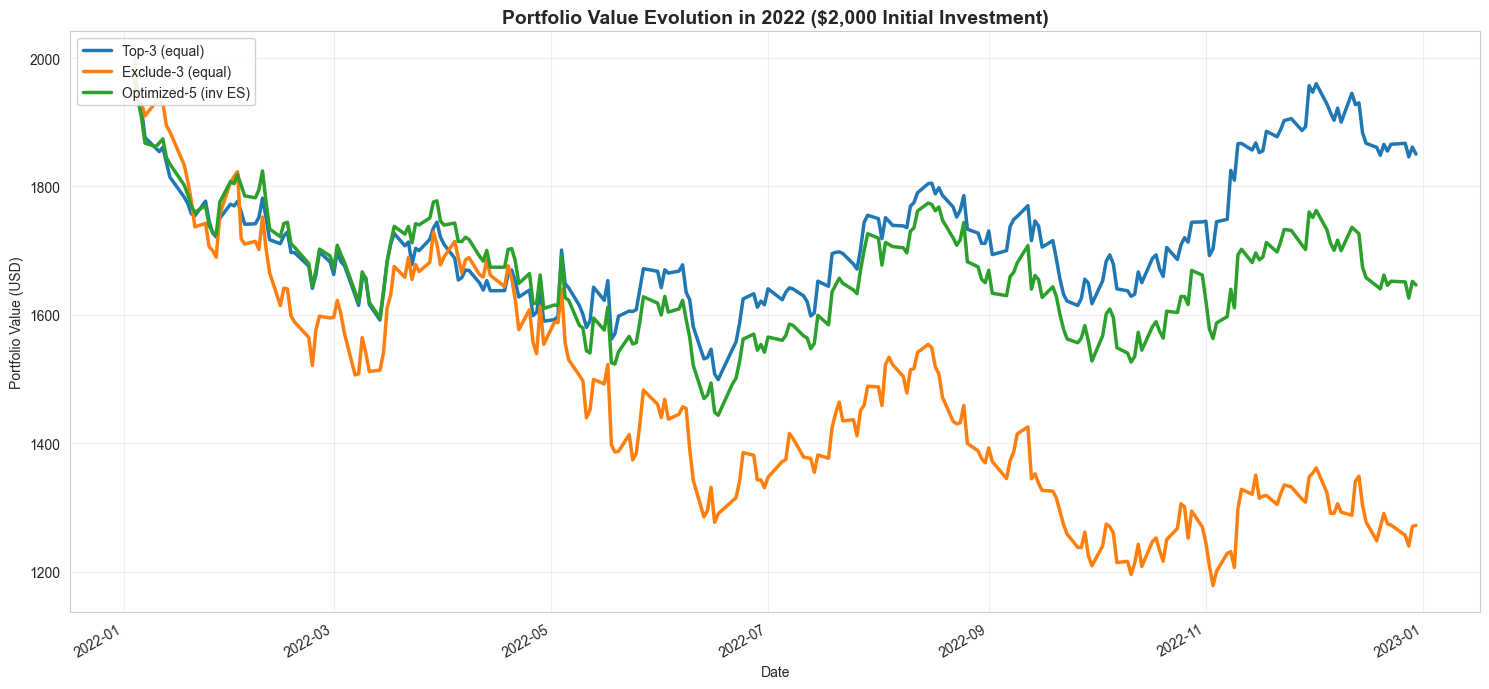

Final portfolio values (2022):
Top-3 (equal)           1850.37
Exclude-3 (equal)       1272.07
Optimized-5 (inv ES)    1646.49
Name: 2022-12-30 00:00:00, dtype: float64


In [50]:
### Portfolio Value Evolution (2022)

def portfolio_value(returns, initial_capital=2000):
    return initial_capital * (1 + returns).cumprod()

initial_capital = 2000

value_top3 = portfolio_value(port_top3, initial_capital).loc["2022-01-01":"2022-12-31"]
value_excl = portfolio_value(port_excl, initial_capital).loc["2022-01-01":"2022-12-31"]
value_opt = portfolio_value(port_opt, initial_capital).loc["2022-01-01":"2022-12-31"]

portfolio_values = pd.DataFrame({
    "Top-3 (equal)": value_top3,
    "Exclude-3 (equal)": value_excl,
    "Optimized-5 (inv ES)": value_opt
})

plt.figure(figsize=(15, 7))
portfolio_values.plot(ax=plt.gca(), linewidth=2.5)
plt.title("Portfolio Value Evolution in 2022 ($2,000 Initial Investment)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (USD)")
plt.legend(loc="upper left", framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final portfolio values (2022):")
print(round(portfolio_values.iloc[-1], 2))

## Section 3: Backtesting VaR Models (2023-2024)

### Setup: Portfolio Construction with 2022 Weights

In [51]:
# Ticker to Company Mapping
ticker_to_company = {
    "ZBRA": "Zebra Technologies",
    "MRNA": "Moderna, Inc.",
    "META": "Meta Platforms, Inc.",
    "SBUX": "Starbucks Corporation",
    "ACN": "Accenture plc",
    "EXPD": "Expeditors International",
    "UNH": "UnitedHealth Group",
    "AAPL": "Apple Inc.",
    "TSN": "Tyson Foods",
    "TGT": "Target Corporation",
}

# Backtesting Portfolio Setup
tickers_opt5 = ["UNH", "SBUX", "EXPD", "AAPL", "ZBRA"]
companies_opt5 = [ticker_to_company[t] for t in tickers_opt5]

# Use weights from 2022 optimization
weights = pd.Series({
    "UNH": 0.2853,
    "SBUX": 0.2017,
    "EXPD": 0.1918,
    "AAPL": 0.1963,
    "ZBRA": 0.1249
})
weights = weights / weights.sum()

print("Portfolio Weights for Backtesting:")
print(round(weights, 4))

Portfolio Weights for Backtesting:
UNH     0.2853
SBUX    0.2017
EXPD    0.1918
AAPL    0.1963
ZBRA    0.1249
dtype: float64


Optimized-5 Portfolio Backtesting (2023-2024):
  N = 502, Exceptions = 4, Expected = 5.02, Rate = 0.0080


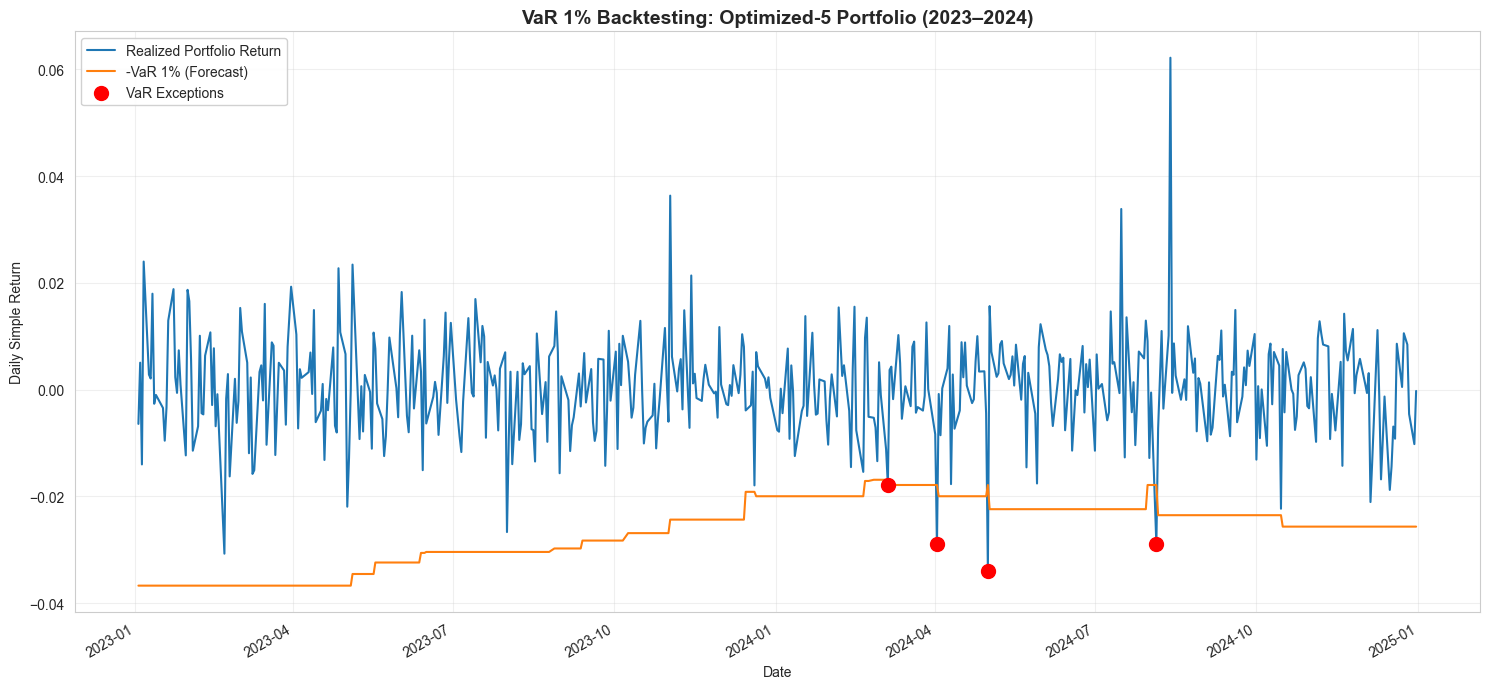

In [52]:
### Backtesting: Optimized-5 Portfolio (2023-2024)

# Use original tickers list
all_tickers_list = tickers  # Use the original tickers from data download

# Calculate portfolio returns using original Daily_returns (with MultiIndex)
def portfolio_returns_bt(df, tickers, weights=None):
    """Portfolio returns for backtesting"""
    R = pd.DataFrame({t: df[(t, "Close")] for t in tickers}).dropna()
    if weights is None:
        w = np.ones(len(tickers)) / len(tickers)
    else:
        w = np.array(weights, dtype=float)
        w = w / w.sum()
    return pd.Series(R.values @ w, index=R.index, name="Portfolio return")

# Optimized portfolio returns
port_ret = portfolio_returns_bt(Daily_returns, tickers_opt5, weights=weights.loc[tickers_opt5].values)

# VaR calculation with rolling window
lookback = 250
alpha = 0.01

VaR = -port_ret.rolling(lookback).quantile(alpha).shift(1)
bt = pd.concat([port_ret, VaR], axis=1).dropna()
bt.columns = ["Portfolio return", "VaR_1pct"]
bt = bt.loc["2023-01-01":"2024-12-31"]

bt["threshold"] = -bt["VaR_1pct"]
bt["exception"] = bt["Portfolio return"] < bt["threshold"]

N = len(bt)
E = int(bt["exception"].sum())
print(f"Optimized-5 Portfolio Backtesting (2023-2024):")
print(f"  N = {N}, Exceptions = {E}, Expected = {0.01*N:.2f}, Rate = {E/N:.4f}")

plt.figure(figsize=(15, 7))
bt["Portfolio return"].plot(label="Realized Portfolio Return", linewidth=1.5)
bt["threshold"].plot(label="-VaR 1% (Forecast)", linewidth=1.5)

exc = bt[bt["exception"]]
plt.scatter(exc.index, exc["Portfolio return"], color="red", s=100, label="VaR Exceptions", marker="o", zorder=5)

plt.title("VaR 1% Backtesting: Optimized-5 Portfolio (2023–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Daily Simple Return")
plt.legend(loc="upper left", framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Equal-Weight Portfolio Backtesting (2023-2024):
  N = 502, Exceptions = 3, Expected = 5.02, Rate = 0.0060


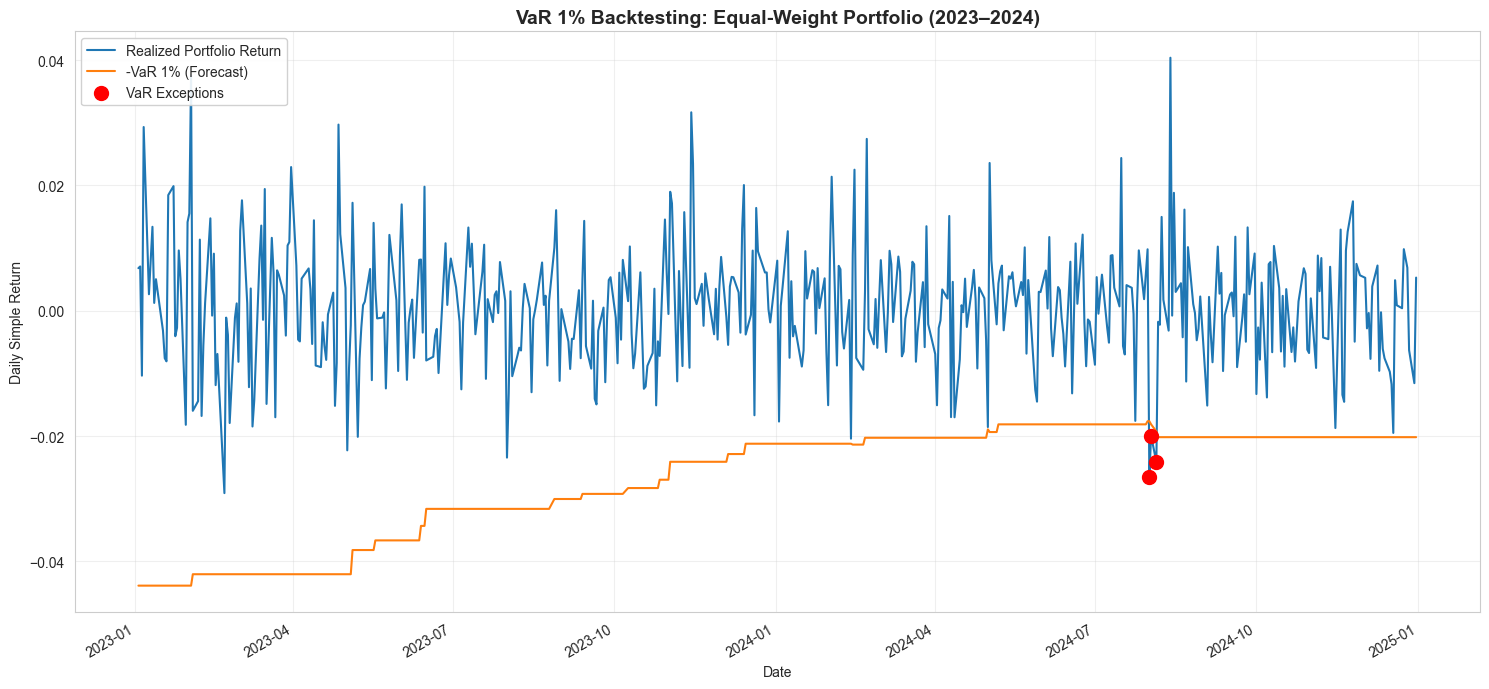

In [53]:
### Backtesting: Equal-Weight Portfolio (All Tickers, 2023-2024)

# Equal-weight portfolio using all original tickers
port_equal = portfolio_returns_bt(Daily_returns, all_tickers_list)

# VaR calculation
VaR_eq = -port_equal.rolling(lookback).quantile(alpha).shift(1)
bt_eq = pd.concat([port_equal, VaR_eq], axis=1).dropna()
bt_eq.columns = ["Portfolio return", "VaR_1pct"]
bt_eq = bt_eq.loc["2023-01-01":"2024-12-31"]

bt_eq["threshold"] = -bt_eq["VaR_1pct"]
bt_eq["exception"] = bt_eq["Portfolio return"] < bt_eq["threshold"]

N_eq = len(bt_eq)
E_eq = int(bt_eq["exception"].sum())
expected_eq = 0.01 * N_eq

print(f"Equal-Weight Portfolio Backtesting (2023-2024):")
print(f"  N = {N_eq}, Exceptions = {E_eq}, Expected = {expected_eq:.2f}, Rate = {E_eq/N_eq:.4f}")

plt.figure(figsize=(15, 7))
bt_eq["Portfolio return"].plot(label="Realized Portfolio Return", linewidth=1.5)
bt_eq["threshold"].plot(label="-VaR 1% (Forecast)", linewidth=1.5)

exc_eq = bt_eq[bt_eq["exception"]]
plt.scatter(exc_eq.index, exc_eq["Portfolio return"], color="red", s=100, label="VaR Exceptions", marker="o", zorder=5)

plt.title("VaR 1% Backtesting: Equal-Weight Portfolio (2023–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Daily Simple Return")
plt.legend(loc="upper left", framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
### Performance Comparison (2024-2025)

# Calculate returns for both strategies over 2024-2025
port_eq_5 = portfolio_returns_bt(Daily_returns, tickers_opt5)
port_opt5 = portfolio_returns_bt(Daily_returns, tickers_opt5, weights=weights.loc[tickers_opt5].values)

start, end = "2024-01-01", "2025-11-01"
r_eq = port_eq_5.loc[start:end].dropna()
r_opt = port_opt5.loc[start:end].dropna()

summary_2425 = pd.DataFrame({
    "Equal-weight (5 tickers)": realized_metrics(r_eq),
    "Optimized-5 (inverse ES)": realized_metrics(r_opt)
}).T

print("\n" + "="*60)
print("PERFORMANCE COMPARISON (2024-01-01 to 2025-11-01)")
print("="*60)
print(round(summary_2425, 4))
print("="*60)



PERFORMANCE COMPARISON (2024-01-01 to 2025-11-01)
                          Mean (daily)  Std (daily)  Sharpe (ann.)  \
Equal-weight (5 tickers)        0.0005       0.0096         0.6321   
Optimized-5 (inverse ES)        0.0004       0.0095         0.4512   

                          Final value (USD, $2000 start)  
Equal-weight (5 tickers)                       2243.9179  
Optimized-5 (inverse ES)                       2181.4861  
